In [1]:
#Plots and data for Experiment 3 in the paper
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import NMF as NMF_sklearn
from scipy import stats
import math

### Dirac3 experiment 3 

In [2]:
#For relative errors
rel_error_dict = {}
rel_error_mad_dict = {}
rel_error_median_dict = {}
#For variable counts
varcounts_dict = {}
varcounts_mad_dict = {}
varcounts_median_dict = {}

In [3]:

#For potts (dirac3 is also known as potts)
#Read the data from all test cases results and prepare information for the plots
type1 = 'potts'#other option is 'qubo'
device = 'dirac3'
for relaxation_schedule in [1]:
    rel_error_mad_dict[(type1, relaxation_schedule)] = []
    rel_error_median_dict[(type1, relaxation_schedule)] = []
    varcounts_mad_dict[(type1, relaxation_schedule)] = []
    varcounts_median_dict[(type1, relaxation_schedule)] = []
    for n in [1,2,3,4]:
        rel_error_dict[(type1,relaxation_schedule,n)] = []
        varcounts_dict[(type1,relaxation_schedule,n)] = []
        for i in range(0,100):
            res_filename = 'res_' + 'mat_'+str(n)+'x'+str(n)+"_"+str(i)+"_"+device +"_sched_"+str(relaxation_schedule)+"_"+str(type1)+".npz"
            res_filepath = "./test_matrices/dirac3_exp3/size_" + str(n) + "x" + str(n) + "/results/" + res_filename

            f = np.load(res_filepath)
            rel_error = float ( f['rel_error'])
            if math.isnan(rel_error):
                rel_error = 0.0
            rel_error_dict[(type1,relaxation_schedule,n)].append(rel_error)
            varcounts_dict[(type1,relaxation_schedule,n)].append(len(f['solutions'][0]))
            f.close()
        #Get the median
        rel_error_median_dict[(type1,relaxation_schedule)].append( np.median(rel_error_dict[(type1,relaxation_schedule,n)] ))
        varcounts_median_dict[(type1,relaxation_schedule)].append( np.median(varcounts_dict[(type1,relaxation_schedule,n)] ))
        #Get the mad
        rel_error_mad_dict[(type1,relaxation_schedule)].append(stats.median_abs_deviation(rel_error_dict[(type1,relaxation_schedule,n)] ))
        varcounts_mad_dict[(type1,relaxation_schedule)].append(stats.median_abs_deviation(varcounts_dict[(type1,relaxation_schedule,n)] ))

In [4]:
#For qubo (dirac3)
#Read the data from all test cases results and prepare information
type1 = 'qubo'
device = 'dirac3'
for relaxation_schedule in [1]:
    rel_error_mad_dict[(type1, relaxation_schedule)] = []
    rel_error_median_dict[(type1, relaxation_schedule)] = []
    varcounts_mad_dict[(type1, relaxation_schedule)] = []
    varcounts_median_dict[(type1, relaxation_schedule)] = []
    for n in [1,2,3]:
        rel_error_dict[(type1,relaxation_schedule,n)] = []
        varcounts_dict[(type1,relaxation_schedule,n)] = []
        for i in range(0,100):
            res_filename = 'res_' + 'mat_'+str(n)+'x'+str(n)+"_"+str(i)+"_"+device +"_sched_"+str(relaxation_schedule)+"_"+str(type1)+".npz"
            res_filepath = "./test_matrices/dirac3_exp3/size_" + str(n) + "x" + str(n) + "/results/" + res_filename

            f = np.load(res_filepath)
            rel_error = float ( f['rel_error'])
            if math.isnan(rel_error):
                rel_error = 0.0
            rel_error_dict[(type1,relaxation_schedule,n)].append(rel_error)
            varcounts_dict[(type1,relaxation_schedule,n)].append(len(f['solutions'][0]))
            f.close()
        #Get the median
        rel_error_median_dict[(type1,relaxation_schedule)].append( np.median(rel_error_dict[(type1,relaxation_schedule,n)] ))
        varcounts_median_dict[(type1,relaxation_schedule)].append( np.median(varcounts_dict[(type1,relaxation_schedule,n)] ))
        #Get the mad
        rel_error_mad_dict[(type1,relaxation_schedule)].append(stats.median_abs_deviation(rel_error_dict[(type1,relaxation_schedule,n)] ))
        varcounts_mad_dict[(type1,relaxation_schedule)].append(stats.median_abs_deviation(varcounts_dict[(type1,relaxation_schedule,n)] ))

In [5]:
#For CP-SAT l1 (sum of abs diff) and l2 (sum of squared diff)
#For qubo (dirac3)
for type1 in ['cpsat_sthread_l1_7','cpsat_sthread_l2_7']:
    for relaxation_schedule in [1]: #do not really need this over here, but keeping it to prevent code from breaking
        rel_error_mad_dict[(type1, relaxation_schedule)] = []
        rel_error_median_dict[(type1, relaxation_schedule)] = []
        varcounts_mad_dict[(type1, relaxation_schedule)] = []
        varcounts_median_dict[(type1, relaxation_schedule)] = []
        for n in [1,2,3,4]:
            rel_error_dict[(type1,relaxation_schedule,n)] = []
            varcounts_dict[(type1,relaxation_schedule,n)] = []
            for i in range(0,100):
                res_filename = 'res_' + 'mat_'+str(n)+'x'+str(n)+"_"+str(i)+"_"+type1+".npz"
                res_filepath = "./test_matrices/dirac3_exp3/size_" + str(n) + "x" + str(n) + "/results/" + res_filename

                f = np.load(res_filepath)
                rel_error = float ( f['rel_error'])
                if math.isnan(rel_error):
                    rel_error = 0.0
                rel_error_dict[(type1,relaxation_schedule,n)].append(rel_error)
                varcounts_dict[(type1,relaxation_schedule,n)].append(f['n_variables'])
                f.close()
            #Get the median
            rel_error_median_dict[(type1,relaxation_schedule)].append( np.median(rel_error_dict[(type1,relaxation_schedule,n)] ))
            varcounts_median_dict[(type1,relaxation_schedule)].append( np.median(varcounts_dict[(type1,relaxation_schedule,n)] ))
            #Get the mad
            rel_error_mad_dict[(type1,relaxation_schedule)].append(stats.median_abs_deviation(rel_error_dict[(type1,relaxation_schedule,n)] ))
            varcounts_mad_dict[(type1,relaxation_schedule)].append(stats.median_abs_deviation(varcounts_dict[(type1,relaxation_schedule,n)] ))

In [6]:
varcounts_median_dict

{('potts', 1): [3.0, 9.0, 19.0, 33.0],
 ('qubo', 1): [15.0, 84.0, 270.0],
 ('cpsat_sthread_l1_7', 1): [8.0, 33.0, 82.0, 161.0],
 ('cpsat_sthread_l2_7', 1): [7.0, 29.0, 73.0, 145.0]}

In [7]:
rel_error_median_dict

{('potts', 1): [0.0,
  0.02771789135603964,
  0.0418770334091797,
  0.051447328222556855],
 ('qubo', 1): [0.0, 0.4645746454134124, 1.5969612573948195],
 ('cpsat_sthread_l1_7', 1): [0.0, 0.0, 0.0, 0.013520985896932347],
 ('cpsat_sthread_l2_7', 1): [0.0, 0.0, 0.0, 0.015718492833447666]}

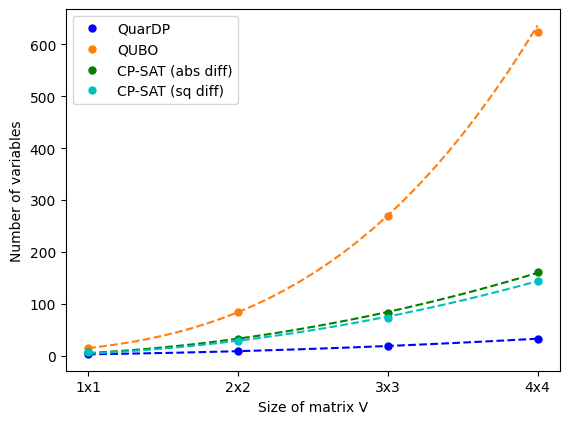

In [8]:
#Plot of number of variables for solvers as a function of the sze of matrix V (no curve fitting for this one)

#The curve fits for the data above was done by Anthropic's Claude Sonnet 4.5 model
fig, ax = plt.subplots()

ax.plot([1,2,3,4],varcounts_median_dict[('potts',1)],color='b',marker='o',markersize=5,linestyle='',label='QuarDP')
ax.plot(np.arange(1,4.1,0.1),[2*(x**2)+1 for x in np.arange(1,4.1,0.1)],linestyle="--",color='b')

#ax.errorbar([1,2,3,4],varcounts_median_dict[('potts',1)],yerr=varcounts_mad_dict[('potts',1)],label='integer',solid_capstyle='projecting', capsize=7, capthick =1.4)
#Note for 4x4 matrices, QUBO method would have produced 624 variables
ax.plot([1,2,3,4],varcounts_median_dict[('qubo',1)] + [624],color='tab:orange',marker='o',markersize=5,linestyle='',label='QUBO')
ax.plot(np.arange(1,4.1,0.1),[10.5*(x**3) - 4.5*(x**2) + 9.0*x + 0 for x in np.arange(1,4.1,0.1)],linestyle="--",color='tab:orange')

#ax.errorbar([1,2,3],varcounts_median_dict[('qubo',1)],yerr=varcounts_mad_dict[('qubo',1)],label='qubo',solid_capstyle='projecting', capsize=7, capthick =1.4)
ax.plot([1,2,3,4],varcounts_median_dict[('cpsat_sthread_l1_7',1)],color='g',marker='o',markersize=5,linestyle='',label='CP-SAT (abs diff)')
ax.plot(np.arange(1,4.1,0.1),[11.86*(x**2) - 7.83*x + 1.31 for x in np.arange(1,4.1,0.1)],linestyle="--",color='g')
#ax.errorbar([1,2,3,4],varcounts_median_dict[('cpsat_sthread_l1_7',1)],yerr=varcounts_mad_dict[('cpsat_sthread_l1_7',1)],label='cpsat',solid_capstyle='projecting', capsize=7, capthick =1.4)

ax.plot([1,2,3,4],varcounts_median_dict[('cpsat_sthread_l2_7',1)],color='c',marker='o',markersize=5,linestyle='',label='CP-SAT (sq diff)')
ax.plot(np.arange(1,4.1,0.1),[10.86*(x**2) - 7.83*x + 1.31 for x in np.arange(1,4.1,0.1)],linestyle="--",color='c')



fig.set_size_inches(4*1.45, 3*1.45)
fig.set_tight_layout(True)

ax.legend()
#ax[0].set_yscale('log')
#ax[1].set_yscale('log')

ax.set_xlabel('Size of matrix V')
ax.set_ylabel('Number of variables')
ax.set_xticks(np.arange(1,5))
ax.set_xticklabels(['1x1','2x2','3x3','4x4'])
plt.savefig("plot_exp3_numvar.pdf")
plt.show()

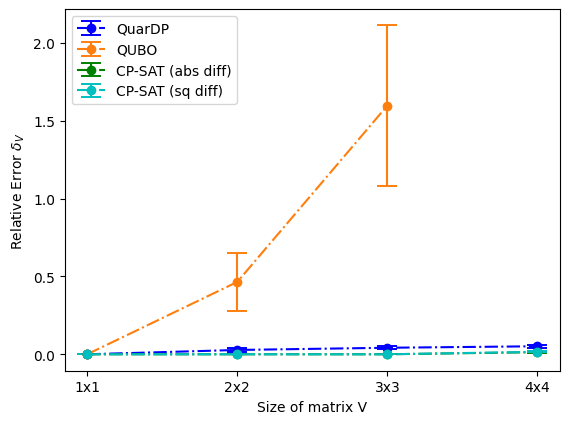

In [9]:
#Plot of rel error as a function of the sze of matrix V (no curve fitting for this one)
fig, ax = plt.subplots()

ax.errorbar([1,2,3,4],rel_error_median_dict[('potts',1)],yerr=rel_error_mad_dict[('potts',1)],label='QuarDP',solid_capstyle='projecting', capsize=7, capthick =1.4,fmt='-.o',color='b')
ax.errorbar([1,2,3],rel_error_median_dict[('qubo',1)],yerr=rel_error_mad_dict[('qubo',1)],label='QUBO',solid_capstyle='projecting', capsize=7, capthick =1.4,fmt='-.o',color='tab:orange')
ax.errorbar([1,2,3,4],rel_error_median_dict[('cpsat_sthread_l1_7',1)],yerr=rel_error_mad_dict[('cpsat_sthread_l1_7',1)],label='CP-SAT (abs diff)',solid_capstyle='projecting', capsize=7, capthick =1.4,fmt='-.o',color='g')
ax.errorbar([1,2,3,4],rel_error_median_dict[('cpsat_sthread_l2_7',1)],yerr=rel_error_mad_dict[('cpsat_sthread_l2_7',1)],label='CP-SAT (sq diff)',solid_capstyle='projecting', capsize=7, capthick =1.4,fmt='-.o',color='c')


fig.set_size_inches(4*1.45, 3*1.45)
fig.set_tight_layout(True)

ax.legend()
#ax[0].set_yscale('log')
#ax[1].set_yscale('log')

ax.set_xlabel('Size of matrix V')
ax.set_ylabel('Relative Error $\delta_{V}$')
ax.set_xticks(np.arange(1,5))
ax.set_xticklabels(['1x1','2x2','3x3','4x4'])

plt.legend(loc="upper left")
plt.savefig("plot_exp3_relerr.pdf")
plt.show()